<a href="https://colab.research.google.com/github/kort3zz/OAD2/blob/main/11_09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('train.csv')
# загрузка данных

In [4]:
print("Строк и столбцов:", df.shape)
print("Столбцы:", list(df.columns))
print("Типы данных:")
print(df.dtypes)
# информация по датасету

Строк и столбцов: (891, 12)
Столбцы: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']
Типы данных:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [5]:
print("Пассажиров по классам:")
print(df['Pclass'].value_counts().sort_index())
print("Мужчин и женщин:")
print(df['Sex'].value_counts())
# анализ пассажиров

Пассажиров по классам:
Pclass
1    216
2    184
3    491
Name: count, dtype: int64
Мужчин и женщин:
Sex
male      577
female    314
Name: count, dtype: int64


In [6]:
bins = [0, 12, 18, 35, 60, 100]
labels = ['ребёнок', 'подросток', 'молодой', 'взрослый', 'пожилой']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)
print("Возрастные группы:")
print(df['AgeGroup'].value_counts())
print("Средний возраст:", round(df['Age'].mean(), 2))
print("Медианный возраст:", df['Age'].median())
print("Средняя стоимость билета:", round(df['Fare'].mean(), 2))
# Разбиваем возраст на группы с помощью pd.cut

Возрастные группы:
AgeGroup
молодой      358
взрослый     195
подросток     70
ребёнок       69
пожилой       22
Name: count, dtype: int64
Средний возраст: 29.7
Медианный возраст: 28.0
Средняя стоимость билета: 32.2


In [7]:
print("Средняя стоимость билета по классам:")
print(df.groupby('Pclass')['Fare'].mean().round(2))
print("Средний возраст по классам:")
print(df.groupby('Pclass')['Age'].mean().round(2))
print("Пол по классам:")
print(df.groupby(['Pclass', 'Sex']).size())
# сравнение классов

Средняя стоимость билета по классам:
Pclass
1    84.15
2    20.66
3    13.68
Name: Fare, dtype: float64
Средний возраст по классам:
Pclass
1    38.23
2    29.88
3    25.14
Name: Age, dtype: float64
Пол по классам:
Pclass  Sex   
1       female     94
        male      122
2       female     76
        male      108
3       female    144
        male      347
dtype: int64


In [8]:
class_counts = df['Pclass'].value_counts()
print("Больше всего пассажиров в классе:", class_counts.idxmax(), f"({class_counts.max()} чел.)")

Больше всего пассажиров в классе: 3 (491 чел.)


In [9]:
most_expensive = df.loc[df['Fare'].idxmax()]
print("Самый дорогой билет:")
print(most_expensive[['Fare', 'Pclass', 'Age', 'Sex', 'Survived']])


Самый дорогой билет:
Fare        512.3292
Pclass             1
Age             35.0
Sex           female
Survived           1
Name: 258, dtype: object


In [10]:
# анализ выживаемости
print("Выжившие/погибшие:")
print(df['Survived'].value_counts().rename({0: 'погиб', 1: 'выжил'}))
surv_by_sex = df.groupby('Sex')['Survived'].mean().round(3)
print("Доля выживших по полу:")
print(surv_by_sex)
surv_by_class_sex = df.groupby(['Pclass', 'Sex'])['Survived'].mean().round(3)
print("Доля выживших по классу и полу:")
print(surv_by_class_sex)
best_group = surv_by_class_sex.idxmax()
print("Наибольшая доля выживших у группы:", best_group, "=", surv_by_class_sex.max())

Выжившие/погибшие:
Survived
погиб    549
выжил    342
Name: count, dtype: int64
Доля выживших по полу:
Sex
female    0.742
male      0.189
Name: Survived, dtype: float64
Доля выживших по классу и полу:
Pclass  Sex   
1       female    0.968
        male      0.369
2       female    0.921
        male      0.157
3       female    0.500
        male      0.135
Name: Survived, dtype: float64
Наибольшая доля выживших у группы: (np.int64(1), 'female') = 0.968


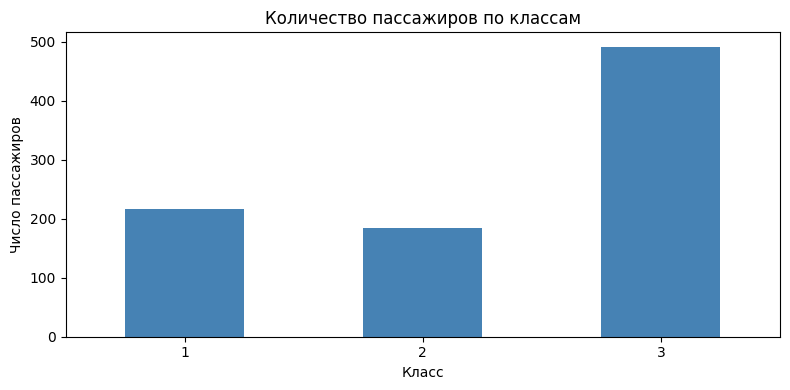

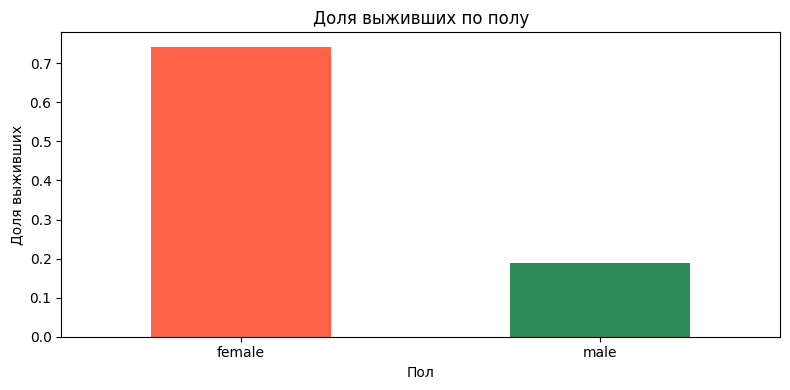

In [11]:
# визуализация
plt.figure(figsize=(8, 4))
df['Pclass'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('Количество пассажиров по классам')
plt.xlabel('Класс')
plt.ylabel('Число пассажиров')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
df.groupby('Sex')['Survived'].mean().plot(kind='bar', color=['tomato', 'seagreen'])
plt.title('Доля выживших по полу')
plt.xlabel('Пол')
plt.ylabel('Доля выживших')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [15]:
print("СВОЙ ВОПРОС")
print("Вопрос: кто выживал чаще — мужчины или женщины?")
print(df.groupby('Sex')['Survived'].mean().round(3))
print("Ответ: женщины выживали намного чаще мужчин.")

СВОЙ ВОПРОС
Вопрос: кто выживал чаще — мужчины или женщины?
Sex
female    0.742
male      0.189
Name: Survived, dtype: float64
Ответ: женщины выживали намного чаще мужчин.
